# Exercício:

In [2]:
import pandas as pd
import numpy as np

## 01 – Do exercício 2 da aula 15, exporte o objeto DataFrame contendo as frequências absolutas de cada aminoácido em cada proteína para .csv, instancie um objeto da classe DataFrame. Defina uma função que receba qualquer objeto composto unidimensional e que retorne as medidas de tendência central. Qual o valor de média, mediana e moda da Serina nos genes analisados? E do terceiro gene?

In [6]:
df_aminoacid = pd.read_csv("df_aminoacid.csv")

In [10]:
def medidas_tendencia(dados):
    serie = pd.Series(dados)
    
    media = serie.mean()
    mediana = serie.median()
    moda = serie.mode()
    
    return media, mediana, moda.values

media, mediana, moda = medidas_tendencia(df_aminoacid["S"])

print("Serina (todos os genes)")
print("Média:", media)
print("Mediana:", mediana)
print("Moda:", moda)

media3, mediana3, moda3 = medidas_tendencia([df_aminoacid.loc["IL6", "S"]])

print("Terceiro gene (IL6)")
print("Média:", media3)
print("Mediana:", mediana3)
print("Moda:", moda3)

Serina (todos os genes)
Média: 62.6
Mediana: 20.0
Moda: [ 12  19  20  38 224]
Terceiro gene (IL6)
Média: 19.0
Mediana: 19.0
Moda: [19]


## 02 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne a amplitude. Qual o valor de amplitude da Isoleucina? E do último gene?

In [12]:
def amplitude(dados):
    serie = pd.Series(dados)
    return serie.max() - serie.min()

amp_I = amplitude(df_aminoacid["I"])
print("Amplitude da Isoleucina:", amp_I)

amp_gene = amplitude(df_aminoacid.loc["BRCA1"])
print("Amplitude do BRCA1:", amp_gene)

Amplitude da Isoleucina: 73
Amplitude do BRCA1: 214


## 03 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne os quartis. Qual o valor do Q1, Q2 e Q3 da Metionina? E do primeiro gene?

In [16]:
def quartis(dados):
    serie = pd.Series(dados)
    
    Q1 = serie.quantile(0.25)
    Q2 = serie.quantile(0.50)
    Q3 = serie.quantile(0.75)
    
    return Q1, Q2, Q3

Q1, Q2, Q3 = quartis(df_aminoacid["M"])

print("Metionina (M)")
print("Q1:", Q1)
print("Q2:", Q2)
print("Q3:", Q3)

Q1, Q2, Q3 = quartis(df_aminoacid.loc["TP53"])

print("TP53")
print("Q1:", Q1)
print("Q2:", Q2)
print("Q3:", Q3)

Metionina (M)
Q1: 4.0
Q2: 6.0
Q3: 12.0
TP53
Q1: 11.75
Q2: 19.0
Q3: 24.5


## 04 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o intervalo interquartil. Qual o valor do o intervalo interquartil da Ácido Glutâmico? E do penúltimo gene? Obtenha o box plot com as medidas de tendência central para a frequência de aa nesse gene.

In [18]:
def iqr(dados):
    serie = pd.Series(dados)
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    return Q3 - Q1

iqr_E = iqr(df_aminoacid["E"])
print("IQR de E:", iqr_E)

iqr_gene = iqr(df_aminoacid.iloc[-2])
print("IQR do IGF2:", iqr_gene)

IQR de E: 14.0
IQR do IGF2: 7.25


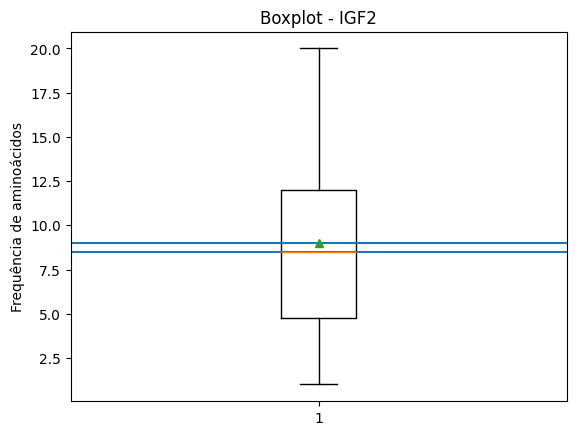

In [20]:
import matplotlib.pyplot as plt

dados_gene = df_aminoacid.iloc[-2]

media = dados_gene.mean()
mediana = dados_gene.median()

plt.figure()
plt.boxplot(dados_gene, showmeans=True)

plt.title("Boxplot - IGF2")
plt.ylabel("Frequência de aminoácidos")

plt.axhline(media)
plt.axhline(mediana)

plt.show()

## 05 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne a variância amostral não viciada. Qual o valor da variância da Prolina? E do terceiro gene?

In [22]:
def variancia_amostral(dados):
    serie = pd.Series(dados)
    return serie.var(ddof=1)

var_P = variancia_amostral(df_aminoacid["P"])
print("Variância da Prolina:", var_P)

var_gene = variancia_amostral(df_aminoacid.loc["IL6"])
print("Variância do IL6:", var_gene)

Variância da Prolina: 1296.8000000000002
Variância do IL6: 42.46315789473683


## 06 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o desvio padrão. Qual o valor d o desvio padrão do Triptofano? E do gene de index -1?

In [23]:
def desvio_padrao(dados):
    serie = pd.Series(dados)
    return serie.std(ddof=1)

dp_W = desvio_padrao(df_aminoacid["W"])
print("Desvio padrão do Triptofano:", dp_W)

dp_gene = desvio_padrao(df_aminoacid.iloc[-1])
print("Desvio padrão do BRCA1:", dp_gene)

Desvio padrão do Triptofano: 3.7815340802378077
Desvio padrão do BRCA1: 54.766754225725784


## 07 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o coeficiente de variação. Qual o valor do coeficiente de variação da Leucina? E do gene de index 1?

In [25]:
def coef_variacao(dados):
    serie = pd.Series(dados)
    return serie.std(ddof=1) / serie.mean()

cv_L = coef_variacao(df_aminoacid["L"])
print("CV da Leucina:", cv_L)

cv_gene = coef_variacao(df_aminoacid.iloc[1])
print("CV do TNF:", cv_gene)


CV da Leucina: 1.090428926550935
CV do TNF: 0.6013583385707334


## 08 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne as medidas resumo.
Obs.: Use um dicionário onde os index são os nomes e os valores as medidas.

In [29]:
def medidas_resumo(dados):
    serie = pd.Series(dados)
    
    resumo = {
        "media": serie.mean(),
        "mediana": serie.median(),
        "moda": serie.mode().values,
        "min": serie.min(),
        "max": serie.max(),
        "amplitude": serie.max() - serie.min(),
        "Q1": serie.quantile(0.25),
        "Q2": serie.quantile(0.50),
        "Q3": serie.quantile(0.75),
        "IQR": serie.quantile(0.75) - serie.quantile(0.25),
        "variancia": serie.var(ddof=1),
        "desvio_padrao": serie.std(ddof=1),
        "coef_variacao": serie.std(ddof=1) / serie.mean()
    }
    
    return resumo

#exemplo:
medidas_resumo(df_aminoacid["S"])

{'media': np.float64(62.6),
 'mediana': np.float64(20.0),
 'moda': array([ 12,  19,  20,  38, 224]),
 'min': np.int64(12),
 'max': np.int64(224),
 'amplitude': np.int64(212),
 'Q1': np.float64(19.0),
 'Q2': np.float64(20.0),
 'Q3': np.float64(38.0),
 'IQR': np.float64(19.0),
 'variancia': np.float64(8232.800000000001),
 'desvio_padrao': np.float64(90.73477833774655),
 'coef_variacao': np.float64(1.4494373536381238)}

## 09 – Defina uma função que retorne qual o gene com o maior CV de frequência de aminoácidos. Obtenha os boxplot dos genes. Os dados concordam? Porque?

C:\Users\CAROL\AppData\Local\Temp\ipykernel_21448\3042149282.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df_aminoacid.T, labels=df_aminoacid.index)


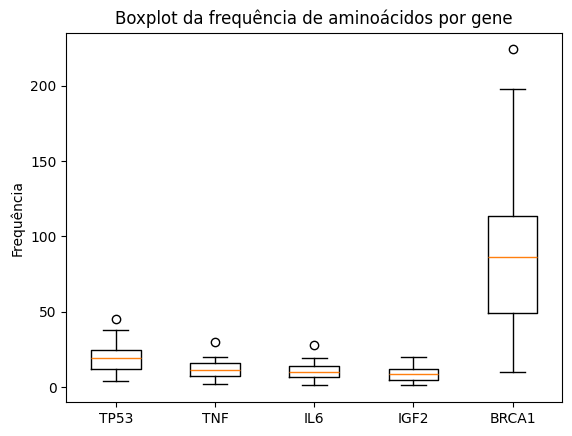

In [31]:
def gene_maior_cv(df_aminoacid):
    cvs = {}
    
    for gene in df_aminoacid.index:
        serie = df_aminoacid.loc[gene]
        cv = serie.std(ddof=1) / serie.mean()
        cvs[gene] = cv
    
    # encontrar maior CV
    maior_gene = max(cvs, key=cvs.get)
    
    return maior_gene, cvs

import matplotlib.pyplot as plt

plt.figure()
plt.boxplot(df_aminoacid.T, labels=df_aminoacid.index)

plt.title("Boxplot da frequência de aminoácidos por gene")
plt.ylabel("Frequência")

plt.show()

In [ ]:
#O gene com maior coeficiente de variação é o BRCA1. Os boxplots confirmam esse resultado, 
#pois esse gene apresenta maior dispersão dos dados, com valores mais extremos e maior variabilidade 
#em comparação aos demais genes (há concordância entre as análises).

## 10 – Defina uma função que retorne qual o aminoácidos com o maior CV dentre os genes. Obtenha os boxplot dos aminoácidos. Os dados concordam? Porque?

Aminoácido com maior CV: N
CVs: {'F': np.float64(0.9464275746019409), 'G': np.float64(1.1250403966809406), 'R': np.float64(0.9323107472135017), 'N': np.float64(1.6294314426273617), 'D': np.float64(1.329461746323327), 'S': np.float64(1.4494373536381238), 'Y': np.float64(1.036523113726489), 'C': np.float64(1.2121830534626528), 'V': np.float64(1.306008050926897), 'Q': np.float64(1.3309078053793784), 'P': np.float64(0.9893161922242443), 'L': np.float64(1.090428926550935), 'E': np.float64(1.4969103983674978), 'M': np.float64(1.0524646102505792), 'K': np.float64(1.5062641391332863), 'T': np.float64(1.3183346471343338), 'W': np.float64(1.050426133399391), 'H': np.float64(1.4258903412626522), 'I': np.float64(1.403581605149501), 'A': np.float64(0.8941566304993069)}


C:\Users\CAROL\AppData\Local\Temp\ipykernel_21448\1758839992.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df_aminoacid, labels=df_aminoacid.columns)


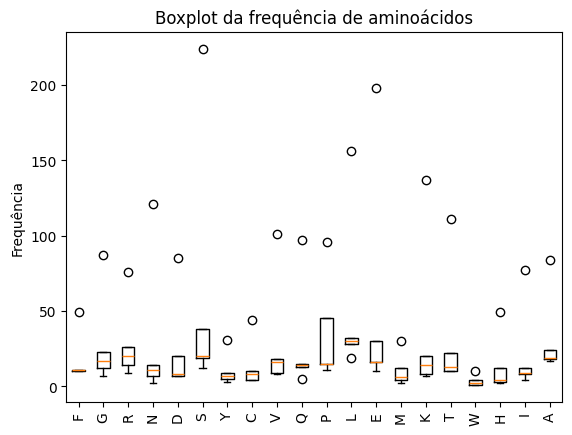

In [37]:
def aa_maior_cv(df_aminoacid):
    cvs = {}
    
    for aa in df_aminoacid.columns:
        serie = df_aminoacid[aa]
        cv = serie.std(ddof=1) / serie.mean()
        cvs[aa] = cv
    
    maior_aa = max(cvs, key=cvs.get)
    
    return maior_aa, cvs


aa, cvs = aa_maior_cv(df_aminoacid)

print("Aminoácido com maior CV:", aa)
print("CVs:", cvs)

import matplotlib.pyplot as plt

plt.figure()
plt.boxplot(df_aminoacid, labels=df_aminoacid.columns)

plt.title("Boxplot da frequência de aminoácidos")
plt.ylabel("Frequência")

plt.xticks(rotation=90)
plt.show()

In [39]:
# O aminoácido com maior coeficiente de variação apresenta maior dispersão nos valores entre os genes,
# o que é confirmado pelo boxplot, onde se observa maior espalhamento e possíveis valores extremos. 
# Portanto há concordância entre as duas análises, pois ambas refletem a variabilidade dos dados.